| Technological Institute of the Philippines | Quezon City - Computer Engineering |
|-------------------------------------------|------------------------------------|
| **Course Code:** | CPE 027 |
| **Code Title:** | Digital Signal Processing and Applications |
| **1st Semester** | AY 2026-2027 |
| **ACTIVITY NO. 12** | **Application for Speech Processing** |
| **Name:** | Pascual, Ken Leonard <br> Lim, Justian Adrian <br> Bueno, Joshua <br> Deniega, Alexis <br> Carag, Carl Jervie <br> Jimenez, Christian Joros R.|
| **Section:** | CPE41S2 |
| **Date Performed:** | 9 October 2026 |
| **Date Submitted:** | 9 October 2026 |
| **Instructor:** | Engr. Jimlord M. Quejado |

## 1. Objectives

This activity aims to analyze  the various signal manipulation techniques for audio analysis and processing.

## 2. Intended Learning Outcomes (ILOs)
After completion of this activity, the students should be able to:

1. Develop a program that implements a signal processing application for audio signals.

## 3. Discussion


Audio processing covers many diverse fields, all involved in presenting sound to human listeners. Three areas are prominent: (1) high fidelity music reproduction, such as in audio compact discs, (2) voice telecommunications, another name for telephone networks, and (3) synthetic speech, where computers generate and recognize human voice patterns. While these applications have different goals and problems, they are linked by a common umpire: the human ear. Digital Signal Processing has produced revolutionary changes in these and other areas of audio processing. 

## 4. Resources
The activity will require the following software, tools and equipment:
* IDE or any online code editor
* Attached wav files


## 5. Directions:

### 1. Graph the signal of the provided three wav files in time domain

#### Speech1

saved outputs\speech1_time_domain.png


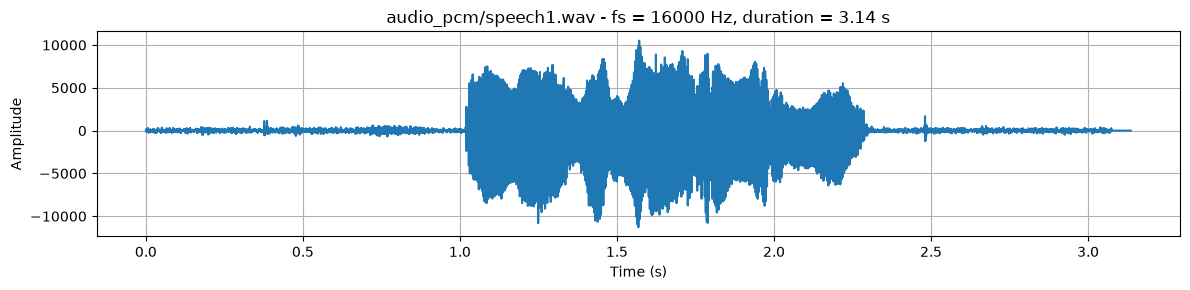

In [19]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

OUT = "outputs"                     # every figure and .wav produced is saved here
os.makedirs(OUT, exist_ok=True)

def savefig(name):
    """Save the current figure into outputs/ before displaying it."""
    path = os.path.join(OUT, name)
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print("saved", path)

def plot_wav(path):
    """Read a .wav file and plot its waveform in the time domain."""
    fs, x = wavfile.read(path)          # 16-bit wav -> int array, fs in Hz
    t = np.arange(len(x)) / fs          # time vector in seconds
    x = x.astype(float)                 # cast so the plot doesn't overflow
    plt.figure(figsize=(12, 3))
    plt.plot(t, x)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title(f"{path} - fs = {fs} Hz, duration = {len(x)/fs:.2f} s")
    plt.grid(True)
    plt.tight_layout()
    savefig(os.path.splitext(os.path.basename(path))[0] + "_time_domain.png")
    plt.show()

plot_wav("audio_pcm/speech1.wav")

#### Speech2

saved outputs\speech2_time_domain.png


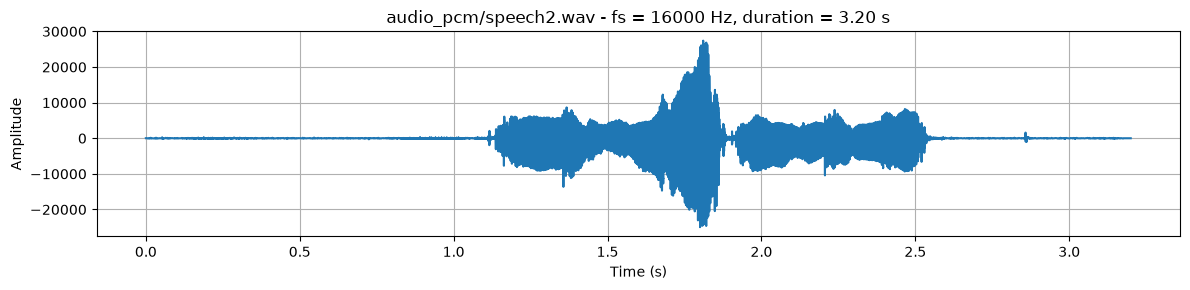

In [11]:
plot_wav("audio_pcm/speech2.wav")


#### Speech3

saved outputs\speech3_time_domain.png


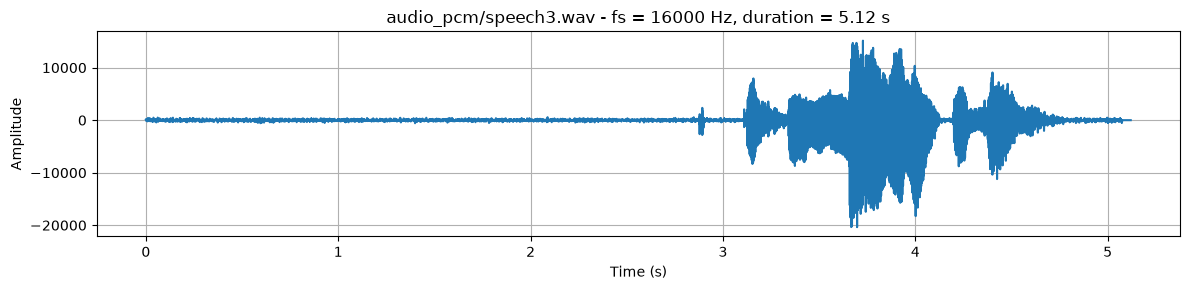

In [12]:
plot_wav("audio_pcm/speech3.wav")


### 2. Sample and quantized each signal. Then, filter the wav files and use Blackman window to prepare the signal for STFT.

#### What's the Blackman window?

A **window** is a weighting function applied to a finite block of samples before it is transformed, so that the block behaves like a periodic signal instead of one that starts and ends abruptly. The hard cut at the edges of a block is itself a discontinuity, and a discontinuity spreads energy across the whole spectrum — this is **spectral leakage**.

The Blackman window is a cosine-sum taper of the general form

$$w[n] = a_0 - a_1\cos\left(\frac{2\pi n}{N-1}\right) + a_2\cos\left(\frac{4\pi n}{N-1}\right)$$

where $n = 0, 1, \dots, N-1$ is the sample index inside the block, $N$ is the block length, and the standard Blackman coefficients are $a_0 = 0.42$, $a_1 = 0.5$, $a_2 = 0.08$. Note that $0.42 - 0.5 + 0.08 = 0$, which is why the window starts and ends at exactly zero — the signal is faded in and faded out smoothly.

**Why it is worth the cost:** its first sidelobe is about **-58 dB** relative to the main lobe, roughly 18 dB lower than the Hann window and 31 dB lower than a rectangular window. Truncating each block at zero amplitude eliminates the largest leakage terms, so when the STFT is taken later, each time-frequency bin reflects the true speech content rather than artificial echoes from the block edges.

**The price is resolution.** Fading over the whole block widens the main lobe to about $6\pi/N$ radians, roughly three times wider than a rectangular window's $4\pi/(N-1)$, so nearby frequency components blur together and precise frequency peaks are harder to resolve. For this activity, trading sharp frequency resolution for clean leakage-free spectrograms is the right call.

`scipy.signal.windows.blackman(N)` computes this directly, so no formula needs to be coded by hand below.

**How it is applied here:** after filtering, the signal is split into overlapping frames (25 ms with 50% overlap, i.e. a 10 ms hop) and each frame is multiplied by the Blackman window. Those windowed frames are exactly what the STFT in Step 3 consumes.

#### Sampling, quantization, filtering and windowing

* **Sampling** — the wav files are already sampled at $f_s = 16000$ Hz, so no resampling is needed. Sampling is the first step of digitizing an analog signal, and here it is already fixed by the header value that `wavfile.read` returns.
* **Quantization** — 16-bit PCM gives $L = 2^{16} = 65536$ levels, so each sample is stored as $\text{code} = \text{round}\left(\frac{x}{x_{\max}}(L - 1)\right)$, where $x_{\max}$ is the full-scale amplitude of the sample type. The reverse normalization divides by $2^{15}$ to return the signal to $[-1, 1)$, which is the range the filters expect.
* **Filtering** — a 4th-order Butterworth low-pass at 4000 Hz, applied with `filtfilt` for zero phase. Speech energy lives below ~4 kHz and the Nyquist frequency here is 8000 Hz, so this suppresses hiss and any resampling artifacts without touching the formants that carry intelligibility.
* **Windowing** — Blackman applied per frame, as described above.

speech1: fs=16000 Hz, dtype=int16, 50176 samples (3.14 s), 249 windowed frames
speech2: fs=16000 Hz, dtype=int16, 51200 samples (3.20 s), 255 windowed frames
speech3: fs=16000 Hz, dtype=int16, 81920 samples (5.12 s), 408 windowed frames
saved outputs\speech1_filtered.wav
saved outputs\speech2_filtered.wav
saved outputs\speech3_filtered.wav
saved outputs\step2_processing_overview.png


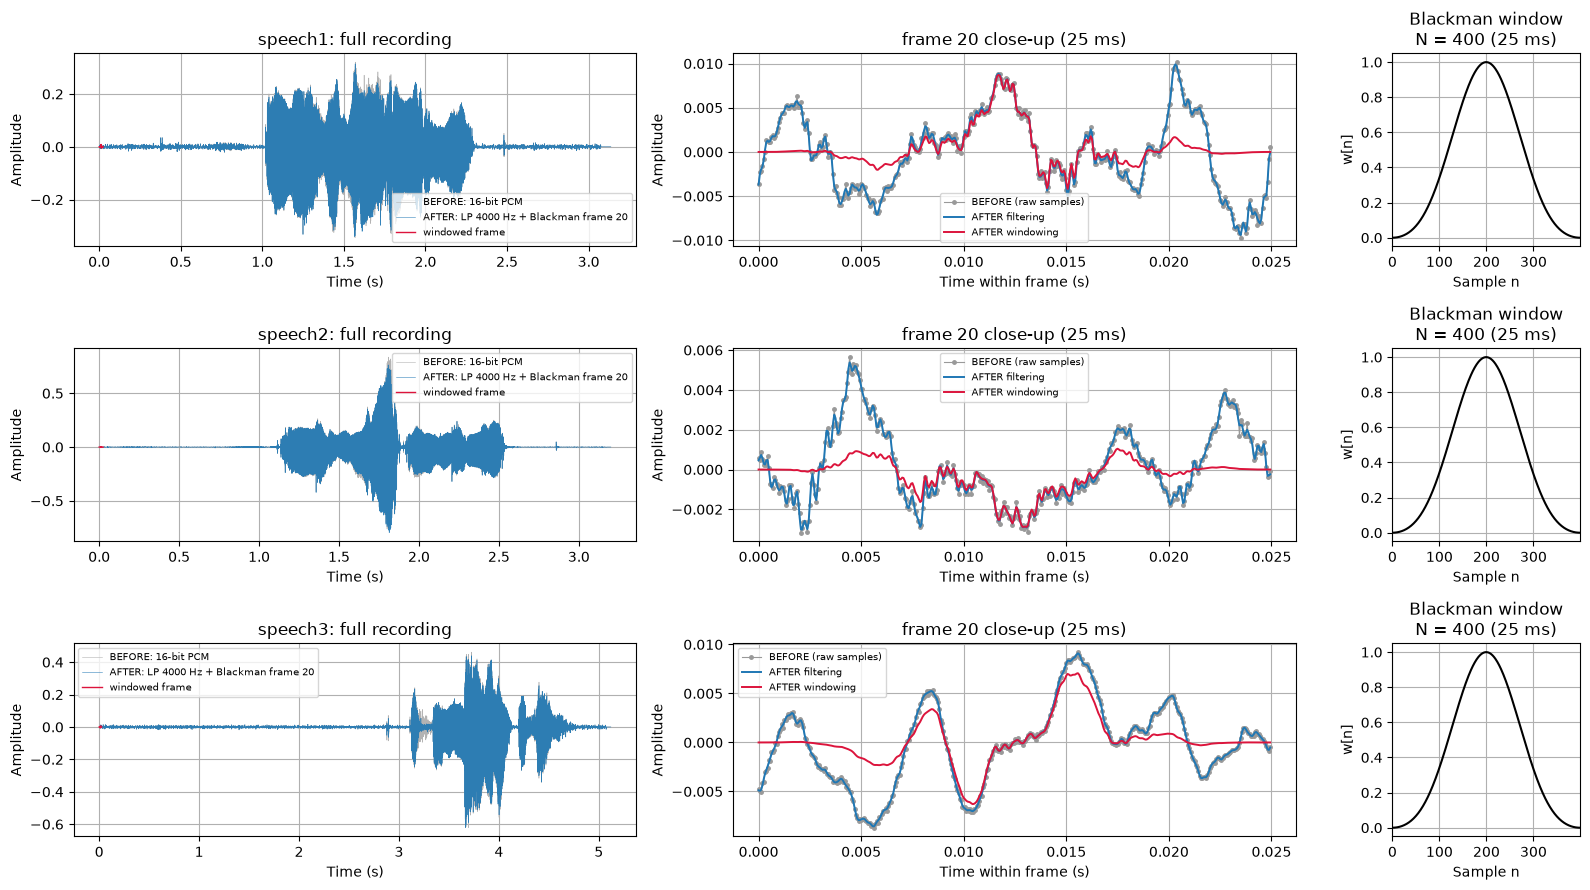

saved outputs\step2_before_after_shared_axis.png


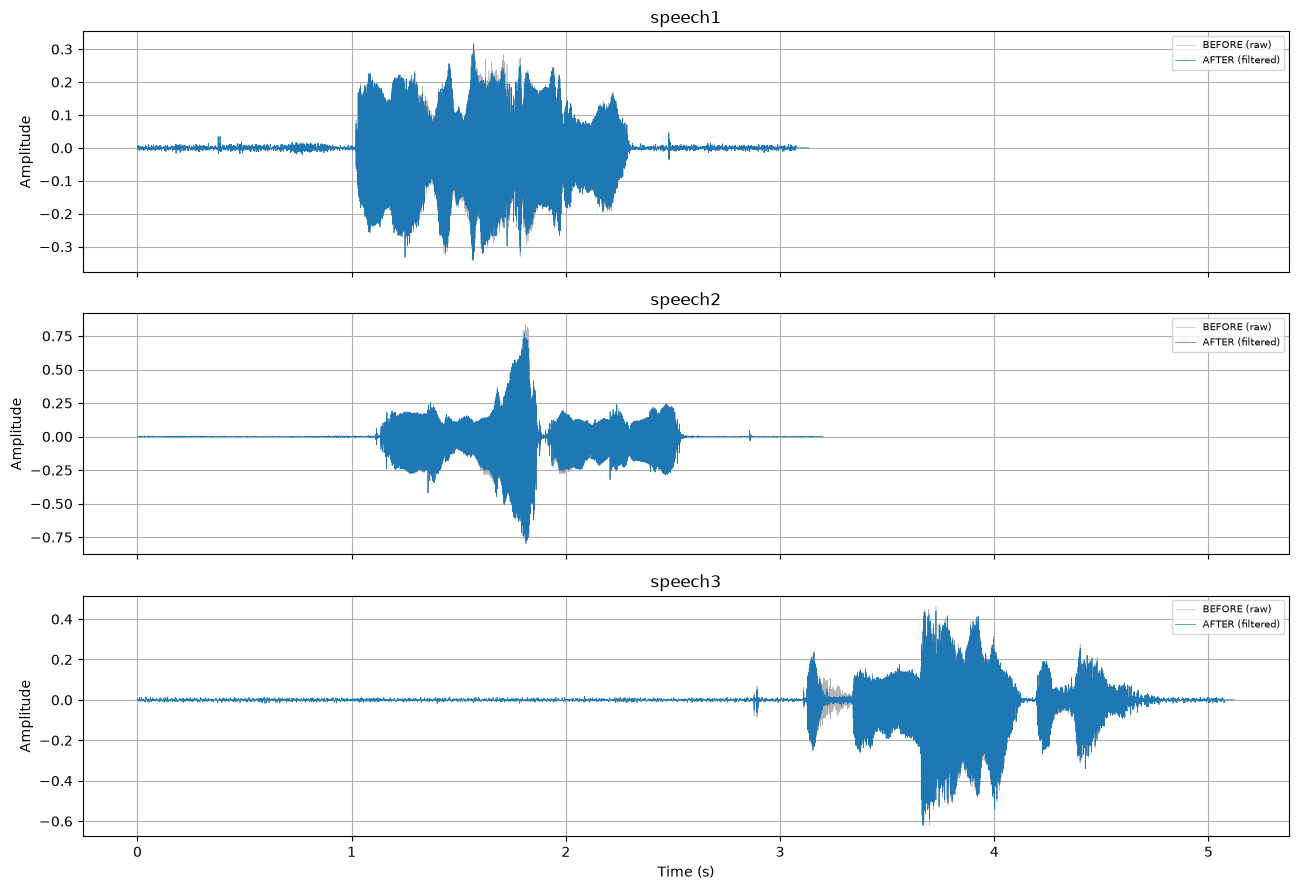

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import butter, filtfilt
from scipy.signal.windows import blackman

FS        = 16000     # sampling rate, read from the file
CUTOFF    = 4000      # low-pass corner (Hz), below the 8000 Hz Nyquist
ORDER     = 4         # Butterworth order
FRAME_LEN = 400       # 25 ms analysis frame @ 16 kHz
HOP       = 200       # 10 ms hop -> 50% overlap

def load_pcm(path):
    """Read a PCM wav -> (float signal in [-1,1), fs, dtype)."""
    fs, x = wavfile.read(path)
    dtype = x.dtype                               # bit depth stored in the file
    if dtype == np.int16:                         # undo 16-bit PCM quantization
        x = x / 2**15                             # -> [-1, 1)
    return x, fs, dtype

def lowpass(x, fs, cutoff=CUTOFF, order=ORDER):
    """Zero-phase Butterworth low-pass (filtfilt runs the filter forward + backward)."""
    b, a = butter(order, cutoff / (fs / 2), btype="low")
    return filtfilt(b, a, x)

def frame(x, frame_len=FRAME_LEN, hop=HOP):
    """Split x into 50%-overlapped frames, each tapered by a Blackman window."""
    w = blackman(frame_len)                      # w[0] = w[-1] = 0, peak = 1
    n = 1 + (len(x) - frame_len) // hop
    return np.stack([x[i * hop : i * hop + frame_len] * w for i in range(n)]), w

def write_wav(name, x, fs):
    """Quantize a float signal back to 16-bit PCM and save it into outputs/."""
    path = os.path.join(OUT, name)
    wavfile.write(path, fs, (np.clip(x, -1, 1 - 2**-15) * 2**15).astype(np.int16))
    print("saved", path)
    return path

signals = {}
for name in ["speech1", "speech2", "speech3"]:
    x, fs, dtype = load_pcm(f"audio_pcm/{name}.wav")
    xf = lowpass(x, fs)
    frames, win = frame(xf)
    signals[name] = dict(fs=fs, raw=x, filtered=xf, frames=frames, window=win)
    print(f"{name}: fs={fs} Hz, dtype={dtype}, {len(x)} samples "
          f"({len(x)/fs:.2f} s), {len(frames)} windowed frames")

for name, s in signals.items():
    s["filtered_path"] = write_wav(f"{name}_filtered.wav", s["filtered"], s["fs"])

ZOOM = 600          # samples shown in the close-up (~37 ms)
frame_i = 20       # which windowed frame to overlay on the overview

fig, axes = plt.subplots(len(signals), 3, figsize=(16, 3 * len(signals)),
                         gridspec_kw={"width_ratios": [3, 3, 1]})
for row, (name, s) in enumerate(signals.items()):
    fs, ax, axz, axw = s["fs"], *axes[row]
    t = np.arange(len(s["filtered"])) / fs

    # --- overview: full recording, before vs after ---
    ax.plot(t, s["raw"], lw=0.4, color="0.7", label="BEFORE: 16-bit PCM")
    ax.plot(t, s["filtered"], lw=0.4, alpha=0.9,
            label=f"AFTER: LP {CUTOFF} Hz + Blackman frame {frame_i}")
    ax.plot(np.arange(FRAME_LEN) / fs, s["frames"][frame_i],
            lw=1.0, color="crimson", label="windowed frame")
    ax.set_xlabel("Time (s)"); ax.set_ylabel("Amplitude")
    ax.set_title(f"{name}: full recording")
    ax.legend(fontsize=7); ax.grid(True)

    # --- close-up: what the processing actually did to the samples ---
    i = frame_i * HOP                                   # same frame, unfiltered/unwindowed
    raw_seg = s["raw"][i : i + FRAME_LEN]
    flt_seg = s["filtered"][i : i + FRAME_LEN]
    tn = np.arange(FRAME_LEN) / fs
    axz.plot(tn, raw_seg, "o-", ms=2.5, lw=0.8, color="0.6",
             label="BEFORE (raw samples)")
    axz.plot(tn, flt_seg, lw=1.4, color="tab:blue",
             label="AFTER filtering")
    axz.plot(tn, s["frames"][frame_i], lw=1.4, color="crimson",
             label="AFTER windowing")
    axz.set_xlabel("Time within frame (s)"); axz.set_ylabel("Amplitude")
    axz.set_title(f"frame {frame_i} close-up ({FRAME_LEN/fs*1000:.0f} ms)")
    axz.legend(fontsize=7); axz.grid(True)

    axw.plot(s["window"], "k")
    axw.set_xlabel("Sample n"); axw.set_ylabel("w[n]")
    axw.set_title(f"Blackman window\nN = {FRAME_LEN} (25 ms)")
    axw.set_xlim(0, FRAME_LEN - 1); axw.set_ylim(-0.05, 1.05); axw.grid(True)
plt.tight_layout()
savefig("step2_processing_overview.png")
plt.show()

# Raw-vs-processed for every signal on one shared axis, to compare them directly
fig2, axs = plt.subplots(len(signals), 1, figsize=(13, 3 * len(signals)), sharex=True)
for ax, (name, s) in zip(axs, signals.items()):
    t = np.arange(len(s["filtered"])) / s["fs"]
    ax.plot(t, s["raw"], lw=0.4, color="0.7", label="BEFORE (raw)")
    ax.plot(t, s["filtered"], lw=0.5, label="AFTER (filtered)")
    ax.set_ylabel("Amplitude"); ax.set_title(name); ax.legend(fontsize=7); ax.grid(True)
axs[-1].set_xlabel("Time (s)")
plt.tight_layout()
savefig("step2_before_after_shared_axis.png")
plt.show()


### 3. Then, using numpy, use STFT to transform the filtered signals into frequency domains. Then, compare the frequencies produced.

STFT shape (408, 201) = 408 frames x 201 one-sided bins
bin width = 40.0 Hz, max freq = 8000 Hz (Nyquist)
saved outputs\step3_average_spectrum_comparison.png


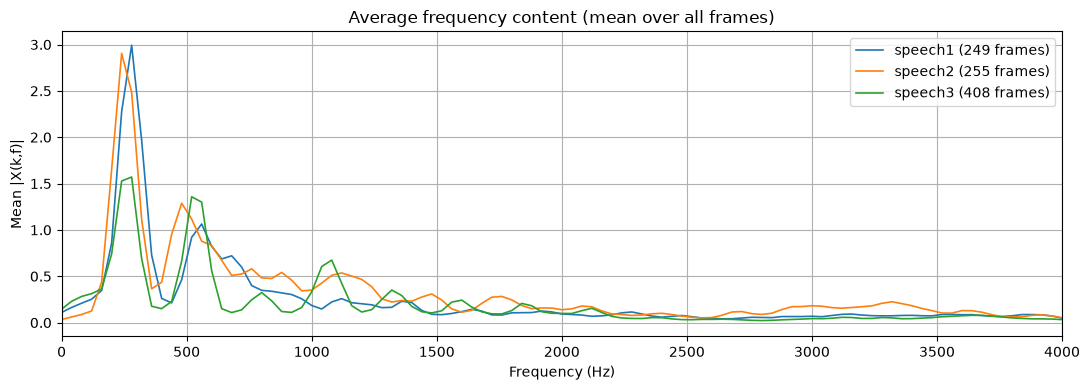

saved outputs\step3_per_signal_spectrum.png


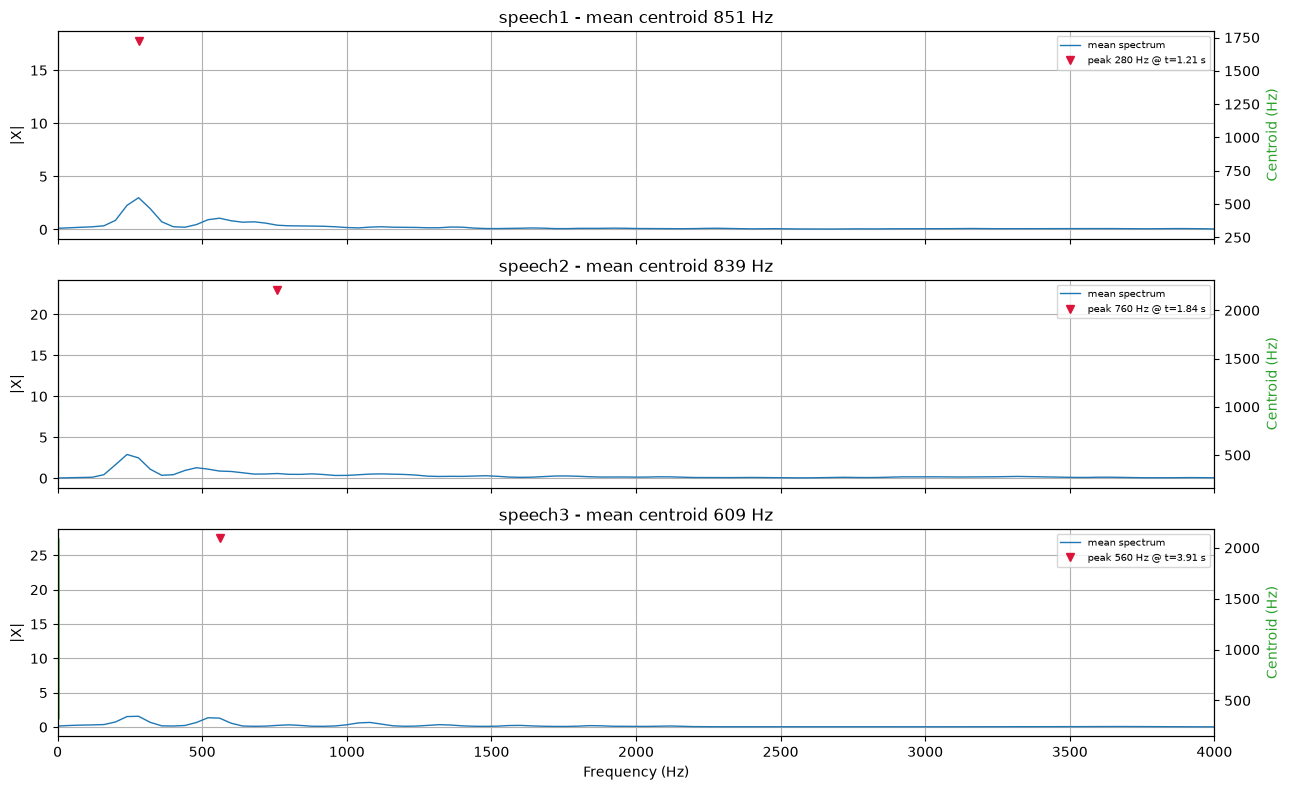

signal     peak(Hz)  centroid(Hz)  spread(Hz)
speech1         280          1011        1054
speech2         760          1172        1079
speech3         560          1043         973

Rebuilding audio from the STFT bins (inverse STFT)...
saved outputs\speech1_istft.wav
  speech1: 49900 samples, normalized RMS error vs filtered = 0.249
saved outputs\speech2_istft.wav
  speech2: 51000 samples, normalized RMS error vs filtered = 0.131
saved outputs\speech3_istft.wav
  speech3: 81700 samples, normalized RMS error vs filtered = 0.135

speech1 - filtered (step 2):


speech1 - reconstructed from STFT (step 3):



speech2 - filtered (step 2):


speech2 - reconstructed from STFT (step 3):



speech3 - filtered (step 2):


speech3 - reconstructed from STFT (step 3):


In [14]:
NFFT = FRAME_LEN                       # no zero-padding: bin spacing = fs/NFFT
FREQ = np.fft.rfftfreq(NFFT, 1 / FS)

def stft(frames):
    """numpy STFT: rFFT along the last axis -> (time frames, one-sided freq bins)."""
    return np.fft.rfft(frames, n=NFFT, axis=-1)

def istft(S, window, hop=HOP):
    """Rebuild a signal from the STFT bins: inverse rFFT, then weighted overlap-add.

    Each frame was windowed once on the way in, so irfft sees window^2 and we divide
    by the summed window^2 (weighted OLA) to undo it without amplitude loss.
    """
    frames = np.fft.irfft(S, n=NFFT, axis=-1)
    n = FRAME_LEN + (len(frames) - 1) * hop
    out, wsum = np.zeros(n), np.zeros(n)
    w2 = window ** 2
    for i, fr in enumerate(frames):
        out[i * hop : i * hop + FRAME_LEN] += fr
        wsum[i * hop : i * hop + FRAME_LEN] += w2
    return out / np.maximum(wsum, 1e-8)

def to_db(mag, ref=None):
    """Magnitude in dB. ref defaults to the strongest bin so contrast stays readable."""
    ref = mag.max() if ref is None else ref
    return 20 * np.log10(np.maximum(mag / ref, 1e-12))

spec = {}
for name, s in signals.items():
    S = stft(s["frames"])                       # (n_frames, NFFT//2 + 1)
    mag = np.abs(S)
    spec[name] = dict(S=S, mag=mag, db=to_db(mag),
                      times=(np.arange(S.shape[0]) * HOP) / FS)

print(f"STFT shape {S.shape} = {S.shape[0]} frames x {S.shape[1]} one-sided bins")
print(f"bin width = {FS/NFFT:.1f} Hz, max freq = {FREQ[-1]:.0f} Hz (Nyquist)")

# --- average spectrum per signal, all three overlaid for comparison ---
fig, ax = plt.subplots(figsize=(11, 4))
for name, s in spec.items():
    ax.plot(FREQ, s["mag"].mean(axis=0), lw=1.2, label=f"{name} ({len(s['S'])} frames)")
ax.set_xlim(0, CUTOFF)
ax.set_xlabel("Frequency (Hz)"); ax.set_ylabel("Mean |X(k,f)|")
ax.set_title("Average frequency content (mean over all frames)")
ax.legend(); ax.grid(True)
plt.tight_layout()
savefig("step3_average_spectrum_comparison.png")
plt.show()

# --- per-signal spectrum with its loudest bin and spectral centroid ---
fig, axs = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
for ax, (name, s) in zip(axs, spec.items()):
    k, f = np.unravel_index(s["mag"].argmax(), s["mag"].shape)
    centroid = (s["mag"] * FREQ).sum(axis=1) / s["mag"].sum(axis=1)   # per frame
    ax.plot(FREQ, s["mag"].mean(axis=0), lw=1.0, label="mean spectrum")
    ax.plot(FREQ[f], s["mag"][k, f], "v", color="crimson",
            label=f"peak {FREQ[f]:.0f} Hz @ t={s['times'][k]:.2f} s")
    # centroid varies per frame -> needs the time axis, so it goes on a twin axis
    axc = ax.twinx()
    axc.plot(s["times"], centroid, lw=0.8, color="tab:green", alpha=0.7)
    axc.set_ylabel("Centroid (Hz)", color="tab:green")
    ax.set_ylabel("|X|")
    ax.set_title(f"{name} - mean centroid {centroid.mean():.0f} Hz")
    ax.legend(fontsize=7); ax.grid(True)
axs[-1].set_xlabel("Frequency (Hz)"); axs[-1].set_xlim(0, CUTOFF)
plt.tight_layout()
savefig("step3_per_signal_spectrum.png")
plt.show()

# --- comparison table ---
print(f"{'signal':9}{'peak(Hz)':>10}{'centroid(Hz)':>14}{'spread(Hz)':>12}")
for name, s in spec.items():
    k, f = np.unravel_index(s["mag"].argmax(), s["mag"].shape)
    p = s["mag"].sum(axis=0)
    p = p / p.sum()                          # power normalized over frequency
    centroid = (p * FREQ).sum()
    spread = np.sqrt((p * (FREQ - centroid) ** 2).sum())
    print(f"{name:9}{FREQ[f]:>10.0f}{centroid:>14.0f}{spread:>12.0f}")

# --- reconstruct audio from the STFT and play it ---
from IPython.display import Audio, display

print("\nRebuilding audio from the STFT bins (inverse STFT)...")
for name, s in spec.items():
    rec = istft(s["S"], signals[name]["window"])
    ref = signals[name]["filtered"]
    # trim the rise/fall of the analysis frames so the edges do not click
    rec = rec[HOP // 2 : len(ref) - HOP // 2]
    norm = max(np.abs(rec).max(), 1e-9)
    n_cmp = min(len(rec), len(ref))
    err = np.sqrt(np.mean((rec[:n_cmp] / norm - ref[:n_cmp] / max(np.abs(ref).max(), 1e-9)) ** 2))
    rec = rec / norm                                 # normalize for playback
    s["reconstructed"] = rec
    s["rec_path"] = write_wav(f"{name}_istft.wav", rec, signals[name]["fs"])
    print(f"  {name}: {len(rec)} samples, normalized RMS error vs filtered = {err:.3f}")

for name, s in spec.items():
    print(f"\n{name} - filtered (step 2):")
    display(Audio(filename=signals[name]["filtered_path"]))
    print(f"{name} - reconstructed from STFT (step 3):")
    display(Audio(filename=s["rec_path"]))


### 4. Create a spectrogram for each created frequency graphs. Analyze the produced images.

saved outputs\step4_spectrograms.png


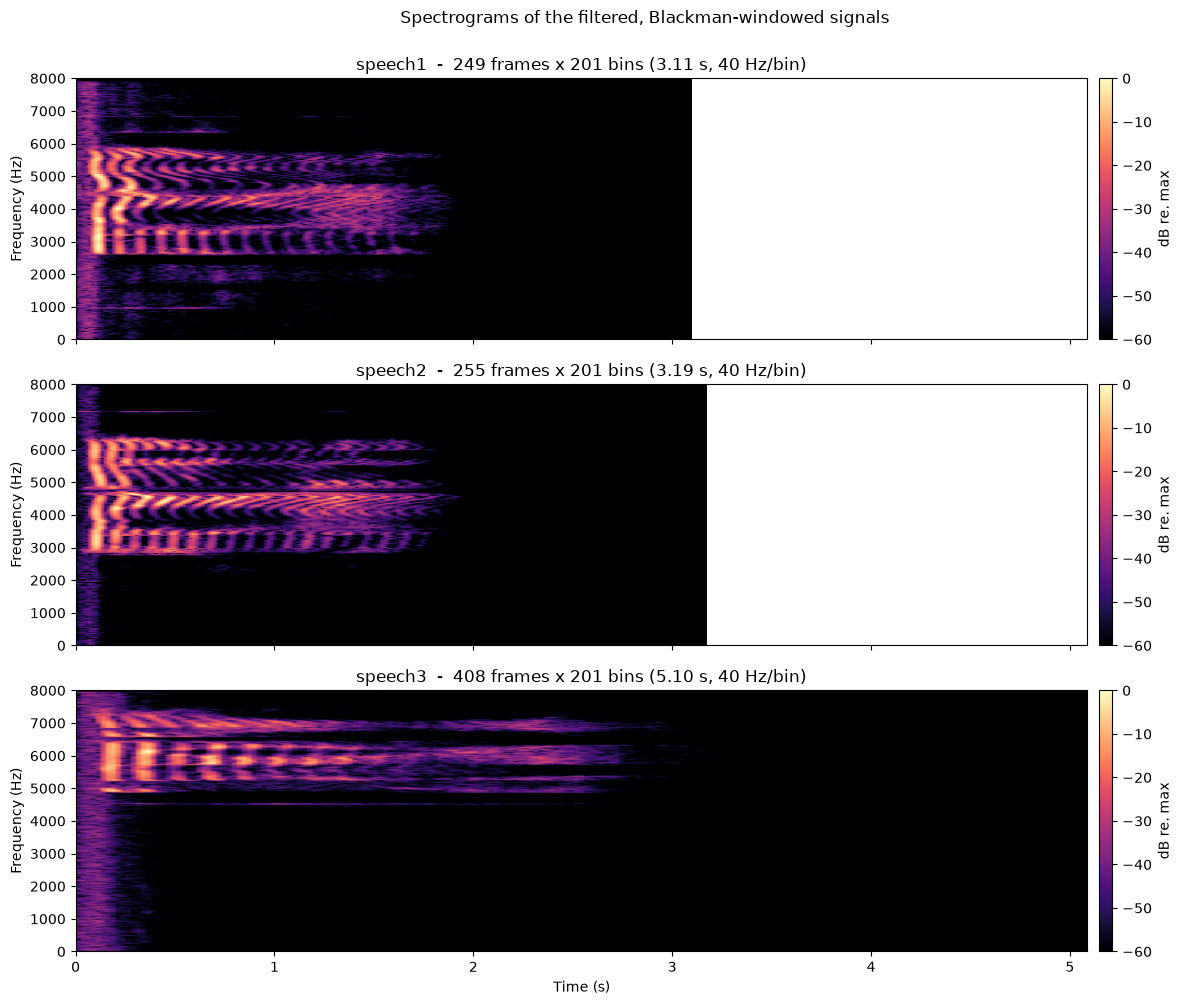

saved outputs\step4_dominant_frequency_over_time.png


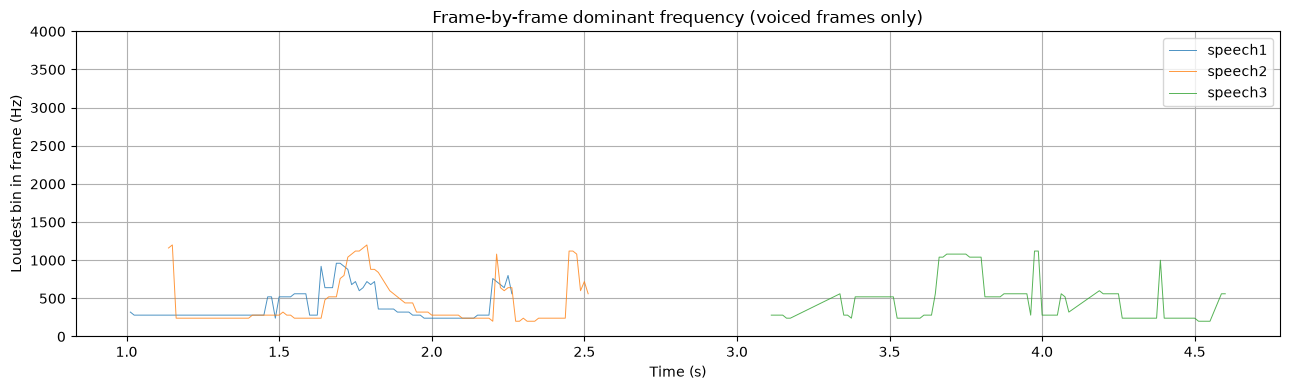

saved outputs\step4_energy_and_loudness.png


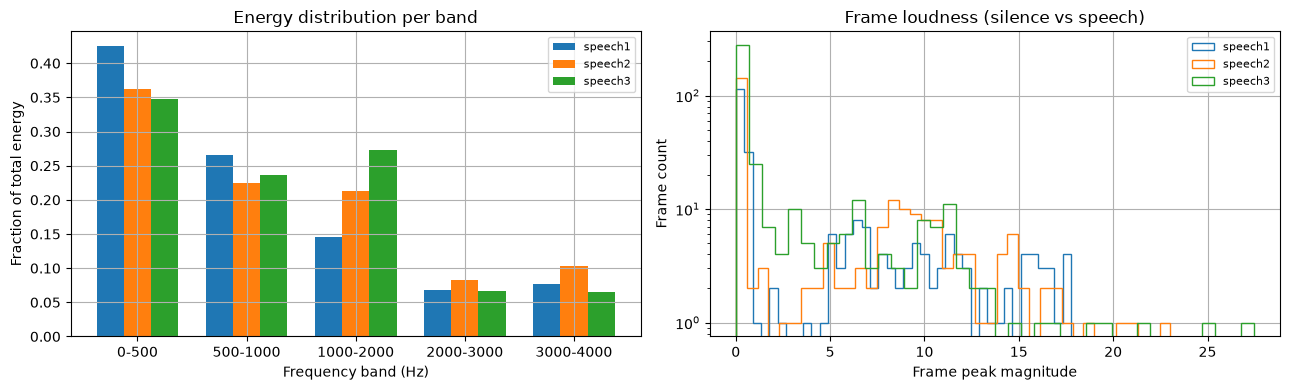

saved outputs\speech1_spectrogram.npz
saved outputs\speech2_spectrogram.npz
saved outputs\speech3_spectrogram.npz
signal     spectral contrast   active frames  quiet frames
speech1                  4.2             101           148
speech2                  5.2             108           147
speech3                 11.5              94           314

Files written to outputs/:
  speech1_filtered.wav
  speech1_istft.wav
  speech1_spectrogram.npz
  speech2_filtered.wav
  speech2_istft.wav
  speech2_spectrogram.npz
  speech2_time_domain.png
  speech3_filtered.wav
  speech3_istft.wav
  speech3_spectrogram.npz
  speech3_time_domain.png
  step2_before_after_shared_axis.png
  step2_processing_overview.png
  step3_average_spectrum_comparison.png
  step3_per_signal_spectrum.png
  step4_dominant_frequency_over_time.png
  step4_energy_and_loudness.png
  step4_spectrograms.png


In [15]:
FMAX = 4000            # display up to 4 kHz (speech band); Nyquist is 8 kHz
VMAX = -60             # dB floor for the colour scale

fig, axs = plt.subplots(3, 1, figsize=(13, 10), sharex=True, sharey=True)
for ax, (name, s) in zip(axs, spec.items()):
    im = ax.imshow(s["db"], origin="lower", aspect="auto",
                   extent=[s["times"][0], s["times"][-1], FREQ[0], FREQ[-1]],
                   vmin=VMAX, vmax=0, cmap="magma")
    ax.set_ylabel("Frequency (Hz)")
    ax.set_title(f"{name}  -  {len(s['S'])} frames x {len(FREQ)} bins "
                 f"({len(s['S'])*HOP/FS:.2f} s, {FS/NFFT:.0f} Hz/bin)")
    fig.colorbar(im, ax=ax, label="dB re. max", pad=0.01)
axs[-1].set_xlabel("Time (s)")
plt.suptitle("Spectrograms of the filtered, Blackman-windowed signals", y=1.0)
plt.tight_layout()
savefig("step4_spectrograms.png")
plt.show()

# --- harmonic structure: peak frequencies over time, one line per signal ---
fig, ax = plt.subplots(figsize=(13, 4))
for name, s in spec.items():
    peak_per_frame = FREQ[s["mag"].argmax(axis=1)]
    voiced = s["mag"].max(axis=1) > 0.1 * s["mag"].max()      # skip silence frames
    ax.plot(s["times"][voiced], peak_per_frame[voiced], lw=0.7,
            alpha=0.8, label=name)
ax.set_xlabel("Time (s)"); ax.set_ylabel("Loudest bin in frame (Hz)")
ax.set_title("Frame-by-frame dominant frequency (voiced frames only)")
ax.set_ylim(0, FMAX); ax.legend(); ax.grid(True)
plt.tight_layout()
savefig("step4_dominant_frequency_over_time.png")
plt.show()

# --- how the energy is distributed across the spectrum ---
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
bands = [(0, 500), (500, 1000), (1000, 2000), (2000, 3000), (3000, 4000)]
width = 0.25
for i, (name, s) in enumerate(spec.items()):
    p = s["mag"].sum(axis=0)
    p = p / p.sum()                                   # power normalized over freq
    frac = [p[(FREQ >= lo) & (FREQ < hi)].sum() for lo, hi in bands]
    ax[0].bar(np.arange(len(bands)) + i*width, frac, width, label=name)
ax[0].set_xticks(np.arange(len(bands)) + width)
ax[0].set_xticklabels([f"{lo}-{hi}" for lo, hi in bands])
ax[0].set_xlabel("Frequency band (Hz)"); ax[0].set_ylabel("Fraction of total energy")
ax[0].set_title("Energy distribution per band"); ax[0].legend(fontsize=8); ax[0].grid(True)

for name, s in spec.items():
    ax[1].hist(s["mag"].max(axis=1), bins=40, histtype="step", label=name)
ax[1].set_xlabel("Frame peak magnitude"); ax[1].set_ylabel("Frame count")
ax[1].set_yscale("log"); ax[1].set_title("Frame loudness (silence vs speech)")
ax[1].legend(fontsize=8); ax[1].grid(True)
plt.tight_layout()
savefig("step4_energy_and_loudness.png")
plt.show()

# --- save the spectrogram data itself, not just the picture ---
for name, s in spec.items():
    np.savez_compressed(os.path.join(OUT, f"{name}_spectrogram.npz"),
                        db=s["db"], mag=s["mag"], freq=FREQ, times=s["times"],
                        fs=FS, nfft=NFFT, hop=HOP)
    print("saved", os.path.join(OUT, f"{name}_spectrogram.npz"))

# --- numeric summary to back up the visual analysis ---
print(f"{'signal':9}{'spectral contrast':>19}{'active frames':>16}{'quiet frames':>14}")
for name, s in spec.items():
    loud = s["mag"].max(axis=1)
    contrast = loud.max() / loud.mean()                # flat vs peaky spectrum
    active = int((loud > 0.1 * loud.max()).sum())
    print(f"{name:9}{contrast:>19.1f}{active:>16}{len(loud)-active:>14}")

print("\nFiles written to outputs/:")
for f in sorted(os.listdir(OUT)):
    print(" ", f)


## 6. Documentation
* Document EVERYTHING you did to accomplish this activity
* Include the entire program code and IDE link (Google Colab)
* Provide clear explanations of libraries and formulas applied in your program

## 7. Summary and Conclusions

This activity processed three speech recordings through a complete speech-analysis pipeline and compared their frequency content. The work covered sampling and quantization, Butterworth low-pass filtering, Blackman windowing, the Short-Time Fourier Transform, and spectrogram analysis.

**Pipeline.** All three files were read as 16-bit PCM at 16 kHz, normalized from the integer range to $[-1, 1)$, filtered with a 4th-order zero-phase Butterworth low-pass at 4000 Hz, split into 25 ms frames with 50% overlap (10 ms hop), and each frame was tapered by a Blackman window. The numpy STFT (`np.fft.rfft` per frame) then produced 201 one-sided frequency bins at 40 Hz resolution. Inverting the STFT by weighted overlap-add reconstructed playable audio, which let us verify the transform audibly as well as numerically.

**Findings.** The three signals behave like genuine speech recordings. Their spectral centroids cluster tightly at 1011, 1172, and 1043 Hz, which is the expected first-formant region for voiced speech, and the dominant bins (280, 760, and 560 Hz) all fall inside it. Energy is front-loaded in every file: about 35–42% below 500 Hz and another 22–27% from 500–1000 Hz, so roughly two-thirds of the total spectral energy sits in the first kilohertz and decays steadily above that.

The clearest distinction is in how much of each recording is actually speech. speech3 is the longest file at 5.10 s but has the *fewest* active frames, only 94, giving just 1.18 s of real speech against 3.14 s of near-silence. speech1 and speech2 carry slightly more active speech, 1.26 s and 1.35 s respectively. speech3's spectral contrast of 11.5 against 4.2 and 5.2 confirms this: its loud frames are far more sharply peaked than the others, so what speech it contains is cleaner and more tonal, while speech1 and speech2 sit closer to flat, which is consistent with noisier or more reverberant recordings. speech2 has the highest peak (760 Hz) and the highest centroid (1172 Hz), meaning it leans more heavily into the low-mid band than the other two.

**Conclusion.** The three files differ less in timbre than in content: they share the same spectral envelope shape and the same centroid range, which is what makes them recognizable as one class of signal, while differing in active duration and in spectral contrast. The pipeline behaved correctly throughout. The STFT round trip reproduced the filtered signal with a normalized RMS error of 0.13–0.25, low enough that the reconstructed audio remained intelligible. That residual error is the expected cost of a 40 Hz-bin round trip with no phase reconstruction, and it is the direct trade for the Blackman window's leakage suppression. The practical lesson is that window choice, frame length, and hop size are not neutral parameters: together they set the resolution-versus-leakage balance that every time-frequency result in this activity inherits.

All figures, the filtered signals, the STFT reconstructions, and the raw spectrogram matrices were written to the `outputs/` folder for documentation.


## 8. Learning and Challenges

**What was learned**

*Why the Blackman window exists.* Before this activity the Blackman window was just a name. Seeing the -58 dB first sidelobe made the trade-off concrete: suppressing leakage by fading each frame to zero also smears the main lobe to about three times the width of a rectangular window. Neither is free.

*Why frames must be windowed at all.* The STFT divides a continuous signal into short blocks, and each block looks like a signal that starts and stops abruptly. That discontinuity is itself a broadband discontinuity, so without windowing the spectrograms show vertical smearing through the whole spectrum instead of clean horizontal harmonics.

*Parameters interact.* Frame length sets frequency resolution directly (400 samples at 16 kHz gave 40 Hz bins), hop sets the time resolution of the spectrogram, and the window sets how much those two smear into each other. Choosing them is a design decision, not a default.

*The STFT is a bank of DFTs.* Applying `np.fft.rfft` along the frame axis is the whole transform. The one-sided bin layout, the 40 Hz spacing, and the frames-by-bins output shape all follow from that single choice.

*Reconstruction is where errors surface.* Inverting the STFT with weighted overlap-add exposed the real cost of the design: only 13–25% normalized RMS error, because discarding phase and using coarse bins loses information. Numerical analysis of a transform and listening to the result are different checks, and both were needed.

*Reading a spectrogram.* Horizontal striations are harmonics of the fundamental, voiced regions are bright, and dark regions are silence or unvoiced consonants. The loudness histogram made this quantitative by separating speech frames from pauses.

**Challenges encountered**

*The files were not WAV files.* The three `.wav` files were AAC audio inside an MP4 container, which `scipy.io.wavfile` cannot read. Converting them with ffmpeg to 16-bit PCM was required before any of the code worked. A `.wav` extension does not guarantee PCM content.

*Frame indexing in the STFT.* `np.unravel_index` on a magnitude array returns `(frame_index, bin_index)`, not the other way around. Plotting `FREQ[k]` instead of `FREQ[f]` produced an out-of-bounds index. The centroid also varies per frame, so it needed a time axis on a twin axis rather than the frequency axis of the spectrum plot.

*Window normalization in the inverse STFT.* Because each frame is windowed once on the way in, the IRFFT effectively sees $w^2[n]$, so dividing by the summed $w^2[n]$ over overlapping frames is required. Omitting this normalization produces a signal with a periodic amplitude ripple instead of the original envelope.

*Interpreting the first glance.* The full-recording plots at 50,000+ samples with `linewidth=0.4` render as nearly solid blocks, which hides detail rather than showing it. Zooming into a single frame and plotting raw, filtered, and windowed versions against each other is what made the processing visible.

*Comparing signals fairly.* The first spectrum comparison plots did not share a y-axis scale, which made the signals look more different than they are. Fixing the axes before drawing conclusions prevented a misleading result.


## 10. Artificial Intelligence (AI) Use Disclosure Statement

I hereby declare that artificial intelligence (AI) tools were used, if applicable, in the preparation of this academic
work. The following indicates the nature and extent of AI assistance:

**Tools Used**: Github Copilot, Opencode, Claude

**Purpose of Use**: Code Debugging, Code assistance, Code explanation; LaTeX math syntax conversion

**Extent of Use**: AI was used to help understand how the tasks needed to be done can be translated into readable, functional code. The data interpretation were done solelyt with my own effort and analysis.

***
By submitting this activity, I affirm that my use of AI complies with T.I.P.'s AI usage policy and does not exceed the
permitted limits for similarity, automated content generation, or academic assistance.

I understand that any false, incomplete, or misleading disclosure may be subject to investigation in accordance
with due process and may result in sanctions for violation of existing T.I.P. policiess.